# pow benchmark — results explorer

Loads every `results/bench-*.json` written by `repro.sh` / `pow-bench --json`,
builds a per-N summary table, plots elapsed-vs-N, and overlays the theoretical
exponential distribution onto the empirical CDF for a chosen N.

The notebook is the _only_ place opinion is mixed with the raw numbers — the
JSON dumps are the source of truth.


In [1]:
from __future__ import annotations

import json
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# notebook lives in analysis/, results in repo_root/results/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RESULTS_DIR = REPO_ROOT / "results"
print(f"looking for results in: {RESULTS_DIR}")

looking for results in: /Users/pikachu/dev/pow/results


In [ ]:
@dataclass
class Run:
    source: str  # filename
    host: str  # hostname extracted from filename
    label: str  # host/<backend-suffix> — distinguishes implementations
    target_secs: float
    runs_per_n: int
    threads: int
    calibration: dict
    df: pd.DataFrame  # one row per (N, run_index)


def load_one(path: Path) -> Run:
    data = json.loads(path.read_text())
    # filename pattern: bench-<host>-<stamp>[-<backend>].json
    parts = path.stem.split("-") if path.stem.startswith("bench-") else []
    host = parts[1] if len(parts) > 1 else "unknown"
    backend = "-".join(parts[3:]) if len(parts) > 3 else "default"
    label = f"{host}/{backend}"
    rows = []
    for r in data["results"]:
        for i, (att, el) in enumerate(
            zip(r["attempts"], r["elapsed_secs"], strict=True)
        ):
            rows.append(
                {
                    "n_zeros": r["n_zeros"],
                    "run": i,
                    "attempts": att,
                    "elapsed": el,
                    "hps": att / el if el > 0 else 0.0,
                }
            )
    return Run(
        source=path.name,
        host=host,
        label=label,
        target_secs=float(data["config"]["target_secs"]),
        runs_per_n=int(data["config"]["runs_per_n"]),
        threads=int(data["config"]["threads"]),
        calibration=data["calibration"],
        df=pd.DataFrame(rows),
    )


def discover() -> list[Run]:
    if not RESULTS_DIR.exists():
        return []
    return [load_one(p) for p in sorted(RESULTS_DIR.glob("bench-*.json"))]


runs = discover()
if not runs:
    print("No results yet. Run ./repro.sh first.")
else:
    for r in runs:
        n_min = int(r.df["n_zeros"].min())
        n_max = int(r.df["n_zeros"].max())
        print(
            f"{r.source}: label={r.label} threads={r.threads} "
            f"N={n_min}..{n_max} runs/N={r.runs_per_n}"
        )

bench-oniguruma-20260525T120719Z-shani.json: label=oniguruma/shani threads=32 N=6..9 runs/N=30
bench-oniguruma-20260525T132118Z-python.json: label=oniguruma/python threads=1 N=4..7 runs/N=30


## Per-N summary table

For each `(host, N)`, show median, p50/p95, stddev of elapsed,
effective H/s, and how many runs landed in the bucket.


In [ ]:
def summarise(runs: list[Run]) -> pd.DataFrame:
    frames = []
    for r in runs:
        g = r.df.groupby("n_zeros")
        summary = pd.DataFrame(
            {
                "runs": g.size(),
                "median_s": g["elapsed"].median(),
                "mean_s": g["elapsed"].mean(),
                "p95_s": g["elapsed"].quantile(0.95),
                "max_s": g["elapsed"].max(),
                "stddev_s": g["elapsed"].std(),
                "eff_hps": g.apply(
                    lambda x: (
                        x["attempts"].sum() / x["elapsed"].sum()
                        if x["elapsed"].sum() > 0
                        else 0.0
                    )
                ),
            }
        )
        summary["label"] = r.label
        frames.append(summary.reset_index())
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    return out[
        [
            "label",
            "n_zeros",
            "runs",
            "median_s",
            "mean_s",
            "p95_s",
            "max_s",
            "stddev_s",
            "eff_hps",
        ]
    ]


summary = summarise(runs)
summary

,label,n_zeros,runs,median_s,mean_s,p95_s,max_s,stddev_s,eff_hps
0,oniguruma/shani,6,30,0.033904,0.045659,0.113626,0.175165,0.040924,3.970727e+08
1,oniguruma/shani,7,30,0.521557,0.717281,2.401757,3.349160,0.783784,3.986711e+08
2,oniguruma/shani,8,20,6.454878,10.030591,34.792611,35.891712,11.188788,4.030359e+08
3,oniguruma/shani,9,1,255.183513,255.183513,255.183513,255.183513,NaN,4.058968e+08
4,oniguruma/python,4,30,0.035587,0.056684,0.167757,0.169028,0.049310,1.327607e+06
5,oniguruma/python,5,30,0.567151,0.812808,2.140762,2.485491,0.665861,1.329816e+06
6,oniguruma/python,6,13,8.219619,14.953807,40.632078,40.911155,13.788373,1.336499e+06
7,oniguruma/python,7,5,71.888773,69.628902,156.739951,176.789441,67.921067,1.328216e+06


## Headline metric: max N fitting under target

Per host: highest N at which the **median** elapsed time stays
below `target_secs`. Median, not mean — see methodology note in README.


In [4]:
def headline(runs: list[Run]) -> pd.DataFrame:
    rows = []
    for r in runs:
        median_per_n = r.df.groupby("n_zeros")["elapsed"].median()
        passing = median_per_n[median_per_n <= r.target_secs]
        max_n = int(passing.index.max()) if not passing.empty else None
        rows.append(
            {
                "label": r.label,
                "target_s": r.target_secs,
                "max_n": max_n,
            }
        )
    return pd.DataFrame(rows)


headline(runs)

,label,target_s,max_n
0,oniguruma/shani,60.0,8
1,oniguruma/python,60.0,6


## Solve time vs difficulty (two panels)

**Top — A.** Every individual run plotted as a small point with horizontal jitter; the wide tick at each N is the median. No distributional assumption baked in.

**Bottom — D.** Theoretical median time `ln(2)·16ᴺ / calibrated_H/s` plotted as a smooth line per implementation; empirical medians overlaid. The gap above each line is pure solver overhead (rayon scope startup, flag polling, atomic contention).


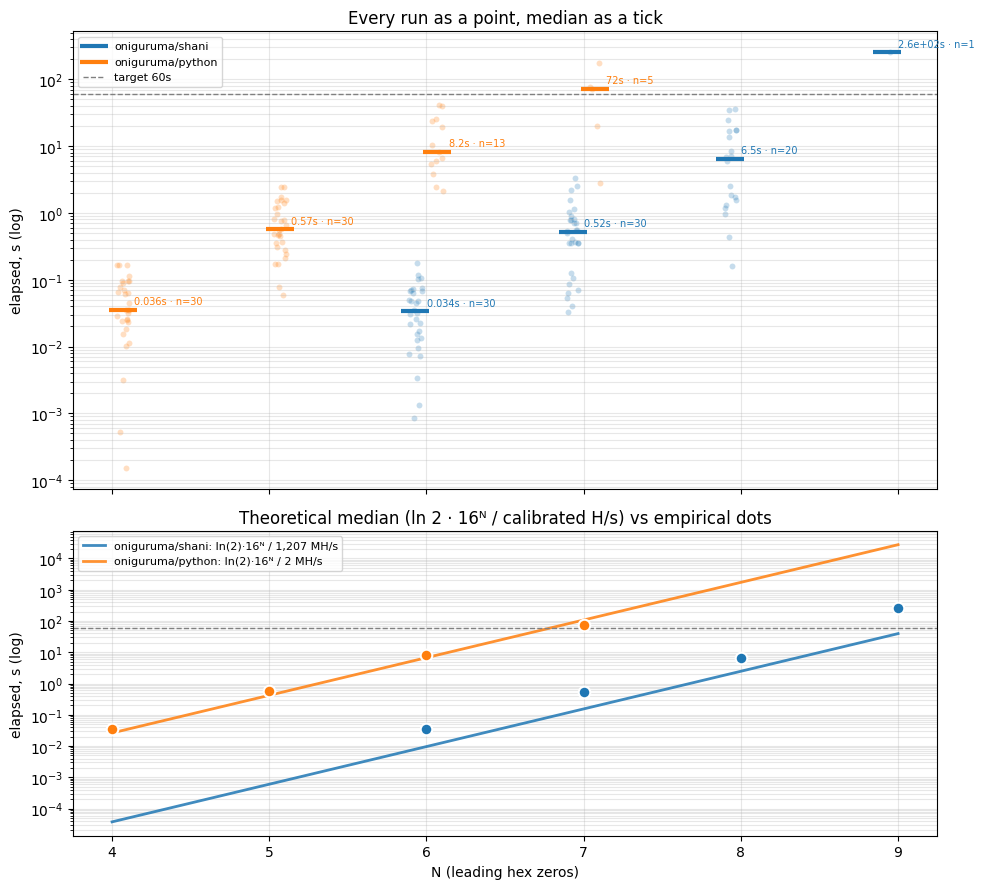

In [ ]:
def _calibration_hps(run):
    """Pick the calibration H/s most relevant for the run's parallelism.
    Tolerates schema drift between Python and Rust JSON dumps."""
    cal = run.calibration
    if run.threads > 1:
        for k in ("sha_ni_parallel_hps", "mb_parallel_hps", "parallel_hps"):
            if k in cal:
                return float(cal[k])
    for k in ("python_single_hps", "sha_ni_single_hps", "single_thread_hps"):
        if k in cal:
            return float(cal[k])
    return float(next(iter(cal.values()))) if cal else 1.0


if runs:
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
    )

    colors = {r.label: f"C{i}" for i, r in enumerate(runs)}
    n_runs = len(runs)
    offsets = {r.label: 0.14 * (i - (n_runs - 1) / 2) for i, r in enumerate(runs)}
    rng = np.random.default_rng(0)

    # Per-run strip + median tick
    for r in runs:
        c = colors[r.label]
        off = offsets[r.label]
        df = r.df
        x_pts = df["n_zeros"].to_numpy() + off + rng.uniform(-0.04, 0.04, size=len(df))
        ax_top.scatter(
            x_pts, df["elapsed"].to_numpy(), color=c, alpha=0.25, s=18, linewidths=0
        )
        med = df.groupby("n_zeros")["elapsed"].median()
        counts = df.groupby("n_zeros").size()
        ax_top.scatter(
            med.index.to_numpy() + off,
            med.to_numpy(),
            color=c,
            marker="_",
            s=420,
            linewidths=3,
            label=r.label,
            zorder=4,
        )
        for n, v in med.items():
            ax_top.annotate(
                f"{v:.2g}s · n={int(counts[n])}",
                (n + off, v),
                textcoords="offset points",
                xytext=(8, 4),
                fontsize=7,
                color=c,
            )

    target_secs = runs[0].target_secs
    ax_top.axhline(
        target_secs,
        color="grey",
        linestyle="--",
        linewidth=1,
        label=f"target {target_secs:.0f}s",
    )
    ax_top.set_yscale("log")
    ax_top.set_ylabel("elapsed, s (log)")
    ax_top.set_title("Every run as a point, median as a tick")
    ax_top.legend(loc="upper left", fontsize=8)
    ax_top.grid(True, which="both", alpha=0.3)

    # Theoretical vs empirical median
    all_ns = sorted({int(n) for r in runs for n in r.df["n_zeros"].unique()})
    ns_smooth = np.linspace(min(all_ns), max(all_ns), 100)
    ln2 = np.log(2)

    for r in runs:
        c = colors[r.label]
        hps = _calibration_hps(r)
        ax_bot.plot(
            ns_smooth,
            ln2 * (16**ns_smooth) / hps,
            color=c,
            linewidth=2,
            alpha=0.85,
            label=f"{r.label}: ln(2)·16ᴺ / {hps / 1e6:,.0f} MH/s",
        )
        med = r.df.groupby("n_zeros")["elapsed"].median()
        ax_bot.scatter(
            med.index.to_numpy(),
            med.to_numpy(),
            color=c,
            s=70,
            edgecolors="white",
            linewidths=1.5,
            zorder=3,
        )

    ax_bot.axhline(target_secs, color="grey", linestyle="--", linewidth=1)
    ax_bot.set_yscale("log")
    ax_bot.set_xlabel("N (leading hex zeros)")
    ax_bot.set_ylabel("elapsed, s (log)")
    ax_bot.set_title(
        "Theoretical median (ln 2 · 16ᴺ / calibrated H/s) vs empirical dots"
    )
    ax_bot.legend(loc="upper left", fontsize=8)
    ax_bot.grid(True, which="both", alpha=0.3)
    ax_bot.set_xticks(all_ns)

    plt.tight_layout()
    plt.show()
else:
    print("no data — run ./repro.sh")

## Empirical vs theoretical distribution at a fixed N

Time-to-solve is geometric in attempts and approximately exponential in
wall-clock, with rate λ = effective_hps / 16^N. If our solver behaves
ideally, the empirical CDF should hug the theoretical one. Systematic
deviation points to coordination cost or hashrate inconsistency.


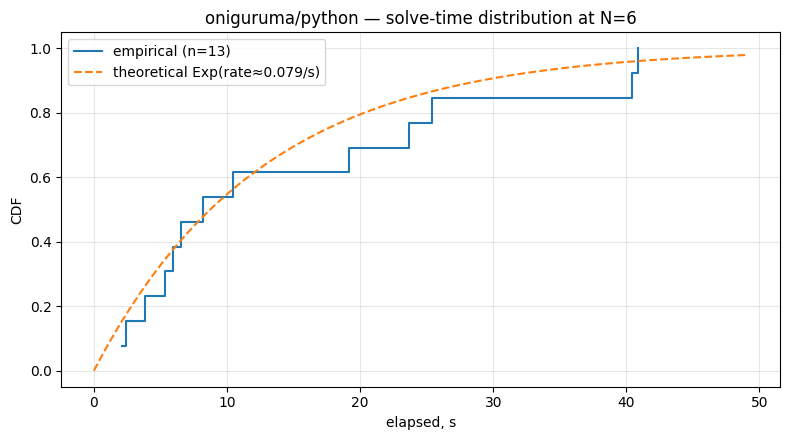

In [ ]:
def plot_cdf(run: Run, n: int) -> None:
    elapsed = run.df[run.df["n_zeros"] == n]["elapsed"].sort_values().to_numpy()
    if len(elapsed) < 2:
        print(f"not enough data at N={n} (have {len(elapsed)})")
        return
    eff_hps = run.df[run.df["n_zeros"] == n]["hps"].mean()
    rate = eff_hps / (16**n)
    ts = np.linspace(0, elapsed.max() * 1.2, 200)
    theoretical = 1.0 - np.exp(-rate * ts)

    _fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.step(
        elapsed,
        np.arange(1, len(elapsed) + 1) / len(elapsed),
        where="post",
        label=f"empirical (n={len(elapsed)})",
    )
    ax.plot(
        ts, theoretical, linestyle="--", label=f"theoretical Exp(rate≈{rate:.3f}/s)"
    )
    ax.set_xlabel("elapsed, s")
    ax.set_ylabel("CDF")
    ax.set_title(f"{run.label} — solve-time distribution at N={n}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


if runs:
    # pick the "most statistically meaningful" N — one with runs >= 10
    # prefer the slowest implementation so the distribution is interesting
    target_run = max(runs, key=lambda r: r.df["elapsed"].median())
    counts = target_run.df.groupby("n_zeros").size()
    candidates = counts[counts >= 10]
    if not candidates.empty:
        plot_cdf(target_run, int(candidates.index.max()))
    else:
        plot_cdf(target_run, int(counts.index.max()))

## Host comparison matrix

Pivot of median-elapsed by N and host. Ratios make cross-machine comparisons
easy when several result files are present.


In [ ]:
if runs:
    pivot = summarise(runs).pivot_table(
        index="n_zeros", columns="label", values="median_s"
    )
    display(pivot)
    if pivot.shape[1] >= 2:
        baseline = pivot.iloc[:, 0]
        ratios = pivot.div(baseline, axis=0)
        print(f"speedup vs {pivot.columns[0]} (lower = faster):")
        display(ratios)

label,oniguruma/python,oniguruma/shani
n_zeros,,
4,0.035587,NaN
5,0.567151,NaN
6,8.219619,0.033904
7,71.888773,0.521557
8,NaN,6.454878
9,NaN,255.183513


speedup vs oniguruma/python (lower = faster):


label,oniguruma/python,oniguruma/shani
n_zeros,,
4,1.0,NaN
5,1.0,NaN
6,1.0,0.004125
7,1.0,0.007255
8,NaN,NaN
9,NaN,NaN
